# Cordex domains

The domain module should give some tools to work with preconfigured or user defined domains. Domains are defined as xarray datasets that will contain dimensions and coodinates according to CF-conventions.

**NOTE**: The domain module mostly focuses on working with rotated cordex domains and how they are defined in the [cordex archive specifications](https://is-enes-data.github.io/cordex_archive_specifications.pdf). However, there are some regional models that use different mappings instead of `rotated_pole` or `rotated_latitude_longitude` which we focus on. Any expertise working with those different mappings is highly welcome!

## Working with domain information

In [1]:
import cordex as cx

The domain module contains some useful functions to work with cordex meta data, e.g., you can get some domain grid information using

In [2]:
cx.domain_info("EUR-11")

{'short_name': 'EUR-11',
 'region': 4,
 'domain_id': 'EUR-12',
 'domain': 'Europe',
 'CORDEX_domain': 'EUR-11',
 'long_name': 'Europe',
 'nlon': 424,
 'nlat': 412,
 'll_lon': -28.375,
 'ur_lon': 18.155,
 'll_lat': -23.375,
 'ur_lat': 21.835,
 'dlon': 0.11,
 'dlat': 0.11,
 'pollon': -162.0,
 'pollat': 39.25}

The domain information is stored in a csv file that is distributed with the `py-cordex` package. You can also directly access the tables using, e.g.

In [3]:
cx.tables.domains

,region,domain_id,domain,CORDEX_domain,long_name,nlon,nlat,ll_lon,ur_lon,ll_lat,ur_lat,dlon,dlat,pollon,pollat
short_name,,,,,,,,,,,,,,,
SAM-44,1,SAM-50,South America,SAM-44,South America,146,167,143.92000,207.72000,-38.28000,34.76000,0.4400,0.4400,-56.06,70.60
CAM-44,2,CAM-50,Central America,CAM-44,Central America,210,113,-52.80000,39.16000,-28.60000,20.68000,0.4400,0.4400,113.98,75.74
NAM-44,3,NAM-50,North America,NAM-44,North America,155,130,-33.88000,33.88000,-28.40000,28.36000,0.4400,0.4400,83.00,42.50
EUR-44,4,EUR-50,Europe,EUR-44,Europe,106,103,-28.21000,17.99000,-23.21000,21.67000,0.4400,0.4400,-162.00,39.25
AFR-44,5,AFR-50,Africa,AFR-44,Africa,194,201,-24.64000,60.28000,-45.76000,42.24000,0.4400,0.4400,180.00,90.00
WAS-44,6,WAS-50,South Asia,WAS-44,South Asia,193,130,-32.12000,52.36000,-21.56000,35.20000,0.4400,0.4400,-123.34,79.95
EAS-44,7,EAS-50,East Asia,EAS-44,East Asia,203,167,-40.92000,47.96000,-26.84000,46.20000,0.4400,0.4400,-64.78,77.61
CAS-44,8,CAS-50,Central Asia,CAS-44,Central Asia,153,100,-34.32000,32.56000,-20.68000,22.88000,0.4400,0.4400,-103.39,43.48
AUS-44,9,AUS-50,Australasia,AUS-44,Australasia,200,129,142.16000,229.72000,-22.88000,33.44000,0.4400,0.4400,141.38,60.31


## `EUR-11` example

The heart of the module are some functions that create a dataset from the grid information, e.g.

In [4]:
eur11 = cx.cordex_domain("EUR-11", dummy="topo")
eur11

/Users/Buntemey/miniforge3/envs/pyremo-dev/lib/python3.13/site-packages/cf_xarray/accessor.py:1004: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  unused_keys = set(attribute.keys()) - set(inverted)
/Users/Buntemey/miniforge3/envs/pyremo-dev/lib/python3.13/site-packages/cf_xarray/accessor.py:1005: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  for key, value in attribute.items():
<frozen _collections_abc>:899: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping

Found operator:topo
# DEBUG - start =============================================================
CALL  :cdo -O -s -f nc -topo,/var/folders/8c/6_nbcgds5cs7nphln4chj4vh0000gp/T/tmpzf3iqlgp /var/folders/8c/6_nbcgds5cs7nphln4chj4vh0000gp/T/cdoPy0_12akad
STDOUT:
STDERR:
# DEBUG - end ===============================================================
RETURNCODE:0


<xarray.Dataset> Size: 4MB
Dimensions:                     (rlon: 424, rlat: 412)
Coordinates:
  * rlon                        (rlon) float64 3kB -28.38 -28.27 ... 18.05 18.16
  * rlat                        (rlat) float64 3kB -23.38 -23.27 ... 21.73 21.84
    lon                         (rlat, rlon) float64 1MB -10.06 -9.964 ... 64.96
    lat                         (rlat, rlon) float64 1MB 21.99 22.03 ... 66.69
Data variables:
    rotated_latitude_longitude  int32 4B 0
    topo                        (rlat, rlon) float32 699kB 284.0 246.0 ... 509.0
Attributes:
    CORDEX_domain:  EUR-11

The `dummy='topo'` argument means, we want a dummy variable in the dataset to see how the domain looks like. For the dummy topography, we use the `cdo topo` operator in the background. So maybe you have to install `python-cdo`, e.g., `conda install -c conda-forge python-cdo`. Working with xarray datasets means, that we can use all the nice functions of xarray including plotting, e.g.,

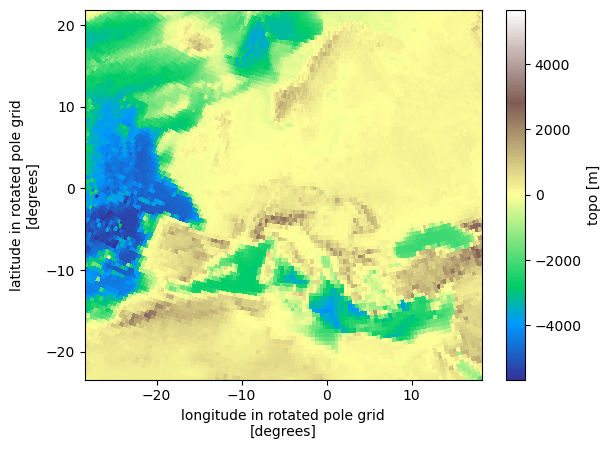

In [5]:
eur11.topo.plot(cmap="terrain")

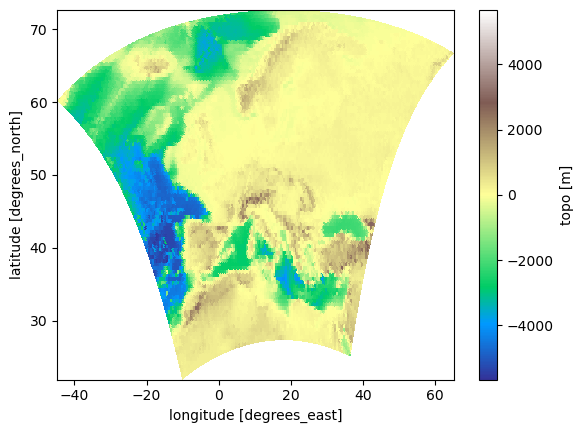

In [6]:
eur11.topo.plot(x="lon", y="lat", cmap="terrain")

Let's define a slightly more sophisticated plotting function that uses cartopy for the right [projection](https://scitools.org.uk/cartopy/docs/latest/tutorials/understanding_transform.html) with a rotated pole:

In [7]:
def plot(da, pole, vmin=None, vmax=None, borders=True, title=None):
    """plot a domain using the right projection with cartopy"""
    %matplotlib inline
    import cartopy.crs as ccrs
    import cartopy.feature as cf
    import matplotlib.pyplot as plt

    plt.figure(figsize=(20, 10))
    projection = ccrs.PlateCarree()
    transform = ccrs.RotatedPole(pole_latitude=pole[1], pole_longitude=pole[0])
    # ax = plt.axes(projection=projection)
    ax = plt.axes(projection=transform)
    # ax.set_extent([ds_sub.rlon.min(), ds_sub.rlon.max(), ds_sub.rlat.min(), ds_sub.rlat.max()], crs=transform)
    ax.gridlines(
        draw_labels=True,
        linewidth=0.5,
        color="gray",
        xlocs=range(-180, 180, 10),
        ylocs=range(-90, 90, 5),
    )
    da.plot(
        ax=ax,
        cmap="terrain",
        transform=transform,
        vmin=vmin,
        vmax=vmax,
        x="rlon",
        y="rlat",
    )
    ax.coastlines(resolution="50m", color="black", linewidth=1)
    if borders:
        ax.add_feature(cf.BORDERS)
    if title is not None:
        ax.set_title(title)

In [8]:
pole = (
    eur11.rotated_latitude_longitude.grid_north_pole_longitude,
    eur11.rotated_latitude_longitude.grid_north_pole_latitude,
)
pole

(-162.0, 39.25)

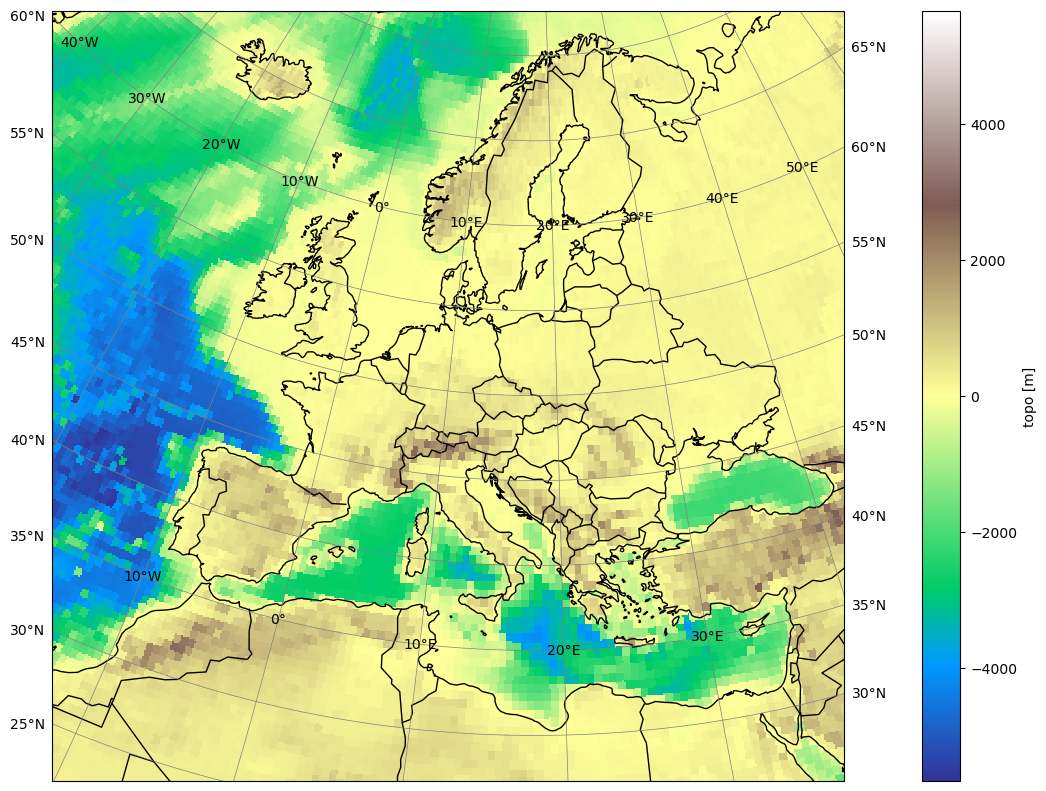

In [9]:
plot(eur11.topo, pole)

## User defined domain

The domains are created using the `create_dataset` function, e.g.:

In [10]:
cx.create_dataset?

Signature:
cx.create_dataset(
    nlon,
    nlat,
    dlon,
    dlat,
    ll_lon,
    ll_lat,
    pollon=None,
    pollat=None,
    name=None,
    domain_id=None,
    dummy=False,
    add_vertices=False,
    attrs=None,
    mapping_name=None,
    bounds=False,
    mip_era='CMIP5',
    cell_area=False,
    **kwargs,
)
Docstring:
Create domain dataset from grid information.

Parameters
----------
nlon : int
    longitudal number of grid boxes
nlat : int
    latitudal number of grid boxes
dlon : float
    longitudal resolution (degrees)
dlat : float
    latitudal resolution (degrees)
ll_lon : float
    lower left longitude (degrees)
ll_lat : float
    lower left latitude (degrees)
pollon : float
    pol longitude (degrees)
pollat : float
    pol latitude (degrees)
domain_id : str
    Domain identifier, goes into the ``CORDEX_domain`` or ``domain_id`` global attribute.
dummy : str or logical
    Name of dummy field, if dummy=topo, the cdo topo operator will be
    used to create some dummy

Let's create the EUR-11 domain manually from the numbers in the table:

In [11]:
eur11_user = cx.create_dataset(
    nlon=424,
    nlat=412,
    dlon=0.11,
    dlat=0.11,
    ll_lon=-28.375,
    ll_lat=-23.375,
    pollon=-162.00,
    pollat=39.25,
)

We can check that this gives the same result as our preconfigured domain.

In [12]:
eur11_user.equals(cx.domain("EUR-11"))

True

You can now use the `create_dataset` function to create any domain as an xarray dataset.

## Check out the Africa domain!

In [13]:
afr11 = cx.cordex_domain("AFR-11", dummy="topo")
afr11

/Users/Buntemey/miniforge3/envs/pyremo-dev/lib/python3.13/site-packages/cf_xarray/accessor.py:1004: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  unused_keys = set(attribute.keys()) - set(inverted)
/Users/Buntemey/miniforge3/envs/pyremo-dev/lib/python3.13/site-packages/cf_xarray/accessor.py:1005: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  for key, value in attribute.items():
<frozen _collections_abc>:899: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping

# DEBUG - start =============================================================
CALL  :cdo -O -s -f nc -topo,/var/folders/8c/6_nbcgds5cs7nphln4chj4vh0000gp/T/tmp822gd_yl /var/folders/8c/6_nbcgds5cs7nphln4chj4vh0000gp/T/cdoPygtumx2hf
STDOUT:
STDERR:
# DEBUG - end ===============================================================
RETURNCODE:0


<xarray.Dataset> Size: 12MB
Dimensions:                     (rlon: 776, rlat: 804)
Coordinates:
  * rlon                        (rlon) float64 6kB -24.8 -24.7 ... 60.34 60.45
  * rlat                        (rlat) float64 6kB -45.92 -45.81 ... 42.3 42.41
    lon                         (rlat, rlon) float64 5MB -24.81 -24.69 ... 60.45
    lat                         (rlat, rlon) float64 5MB -45.93 -45.93 ... 42.41
Data variables:
    rotated_latitude_longitude  int32 4B 0
    topo                        (rlat, rlon) float32 2MB -4.429e+03 ... 161.0
Attributes:
    CORDEX_domain:  AFR-11

In [14]:
pole = (
    afr11.rotated_latitude_longitude.grid_north_pole_longitude,
    afr11.rotated_latitude_longitude.grid_north_pole_latitude,
)
pole

(180.0, 90.0)

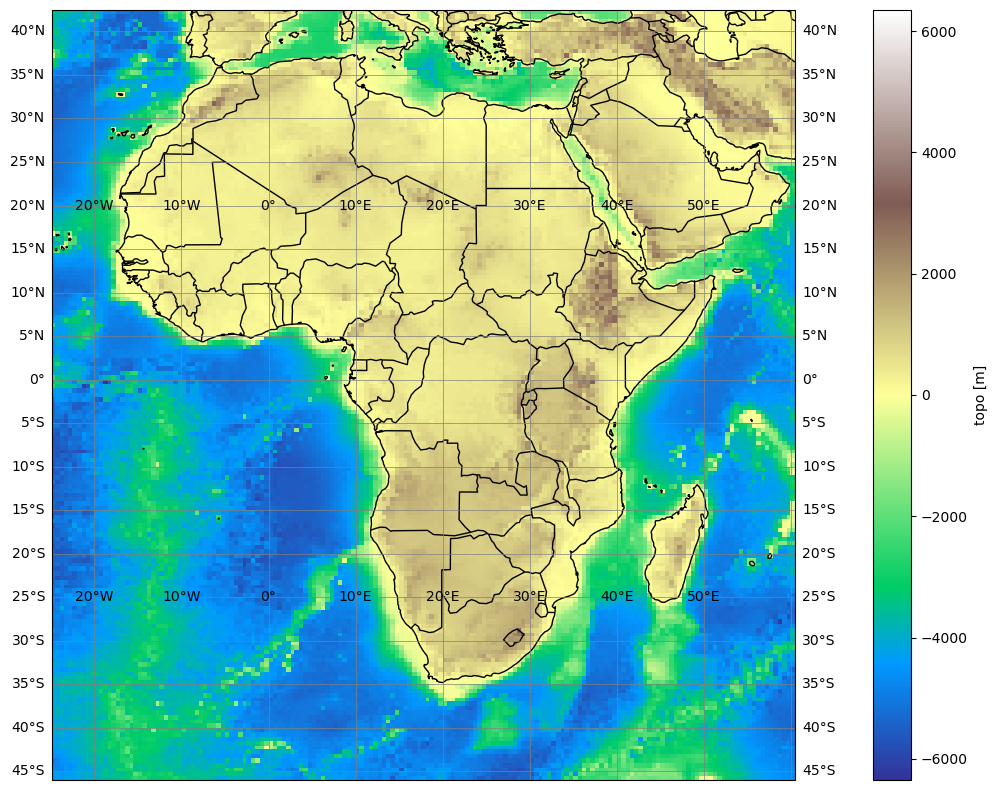

In [15]:
plot(afr11.topo, pole)

## Plot all cordex-core domains

We need a slightly modified plotting routine for this:

In [16]:
def plots(dsets, vmin=None, vmax=None, borders=True, title=None):
    """plot a domain using the right projection with cartopy"""
    %matplotlib inline
    import cartopy.crs as ccrs
    import cartopy.feature as cf
    import matplotlib.pyplot as plt

    plt.figure(figsize=(20, 10))
    projection = ccrs.PlateCarree()
    # transform = ccrs.RotatedPole(pole_latitude=pole[1], pole_longitude=pole[0])
    # ax = plt.axes(projection=projection)
    ax = plt.axes(projection=projection)
    # ax.set_extent([ds_sub.rlon.min(), ds_sub.rlon.max(), ds_sub.rlat.min(), ds_sub.rlat.max()], crs=transform)
    ax.gridlines(
        draw_labels=True,
        linewidth=0.5,
        color="gray",
        xlocs=range(-180, 180, 15),
        ylocs=range(-90, 90, 10),
    )
    # path_effects = [pe.Stroke(linewidth=50, foreground='g'), pe.Normal()]
    for ds in dsets:
        pole = (
            ds.rotated_latitude_longitude.grid_north_pole_longitude,
            ds.rotated_latitude_longitude.grid_north_pole_latitude,
        )
        transform = ccrs.RotatedPole(pole_latitude=pole[1], pole_longitude=pole[0])
        ds.topo.plot(
            ax=ax,
            cmap="terrain",
            transform=transform,
            vmin=vmin,
            vmax=vmax,
            x="rlon",
            y="rlat",
            add_colorbar=False,
        )
    ax.coastlines(resolution="50m", color="black", linewidth=1)
    if borders:
        ax.add_feature(cf.BORDERS)
    if title is not None:
        ax.set_title("")

Now, let's plot all cordex core domains into one overview:

/Users/Buntemey/miniforge3/envs/pyremo-dev/lib/python3.13/site-packages/cf_xarray/accessor.py:1004: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  unused_keys = set(attribute.keys()) - set(inverted)
/Users/Buntemey/miniforge3/envs/pyremo-dev/lib/python3.13/site-packages/cf_xarray/accessor.py:1005: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  for key, value in attribute.items():
<frozen _collections_abc>:899: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping

# DEBUG - start =============================================================
CALL  :cdo -O -s -f nc -topo,/var/folders/8c/6_nbcgds5cs7nphln4chj4vh0000gp/T/tmptoapmrw3 /var/folders/8c/6_nbcgds5cs7nphln4chj4vh0000gp/T/cdoPyfg849cmx
STDOUT:
STDERR:
# DEBUG - end ===============================================================
RETURNCODE:0


/Users/Buntemey/miniforge3/envs/pyremo-dev/lib/python3.13/site-packages/cf_xarray/accessor.py:1004: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  unused_keys = set(attribute.keys()) - set(inverted)
/Users/Buntemey/miniforge3/envs/pyremo-dev/lib/python3.13/site-packages/cf_xarray/accessor.py:1005: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  for key, value in attribute.items():
<frozen _collections_abc>:899: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping

# DEBUG - start =============================================================
CALL  :cdo -O -s -f nc -topo,/var/folders/8c/6_nbcgds5cs7nphln4chj4vh0000gp/T/tmpcuephn78 /var/folders/8c/6_nbcgds5cs7nphln4chj4vh0000gp/T/cdoPy37f9d2pp
STDOUT:
STDERR:
# DEBUG - end ===============================================================
RETURNCODE:0


/Users/Buntemey/miniforge3/envs/pyremo-dev/lib/python3.13/site-packages/cf_xarray/accessor.py:1004: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  unused_keys = set(attribute.keys()) - set(inverted)
/Users/Buntemey/miniforge3/envs/pyremo-dev/lib/python3.13/site-packages/cf_xarray/accessor.py:1005: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  for key, value in attribute.items():
<frozen _collections_abc>:899: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping

...

# DEBUG - start =============================================================
CALL  :cdo -O -s -f nc -topo,/var/folders/8c/6_nbcgds5cs7nphln4chj4vh0000gp/T/tmpsvpzr1a7 /var/folders/8c/6_nbcgds5cs7nphln4chj4vh0000gp/T/cdoPysaen9n6q
STDOUT:
STDERR:
# DEBUG - end ===============================================================
RETURNCODE:0


/Users/Buntemey/miniforge3/envs/pyremo-dev/lib/python3.13/site-packages/cf_xarray/accessor.py:1004: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  unused_keys = set(attribute.keys()) - set(inverted)
/Users/Buntemey/miniforge3/envs/pyremo-dev/lib/python3.13/site-packages/cf_xarray/accessor.py:1005: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  for key, value in attribute.items():
<frozen _collections_abc>:899: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping

# DEBUG - start =============================================================
CALL  :cdo -O -s -f nc -topo,/var/folders/8c/6_nbcgds5cs7nphln4chj4vh0000gp/T/tmphz6vyzti /var/folders/8c/6_nbcgds5cs7nphln4chj4vh0000gp/T/cdoPy1y70ndvr
STDOUT:
STDERR:
# DEBUG - end ===============================================================
RETURNCODE:0


/Users/Buntemey/miniforge3/envs/pyremo-dev/lib/python3.13/site-packages/cf_xarray/accessor.py:1004: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  unused_keys = set(attribute.keys()) - set(inverted)
/Users/Buntemey/miniforge3/envs/pyremo-dev/lib/python3.13/site-packages/cf_xarray/accessor.py:1005: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  for key, value in attribute.items():
<frozen _collections_abc>:899: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping

# DEBUG - start =============================================================
CALL  :cdo -O -s -f nc -topo,/var/folders/8c/6_nbcgds5cs7nphln4chj4vh0000gp/T/tmpc5n_p2uo /var/folders/8c/6_nbcgds5cs7nphln4chj4vh0000gp/T/cdoPyalg57e4i
STDOUT:
STDERR:
# DEBUG - end ===============================================================
RETURNCODE:0


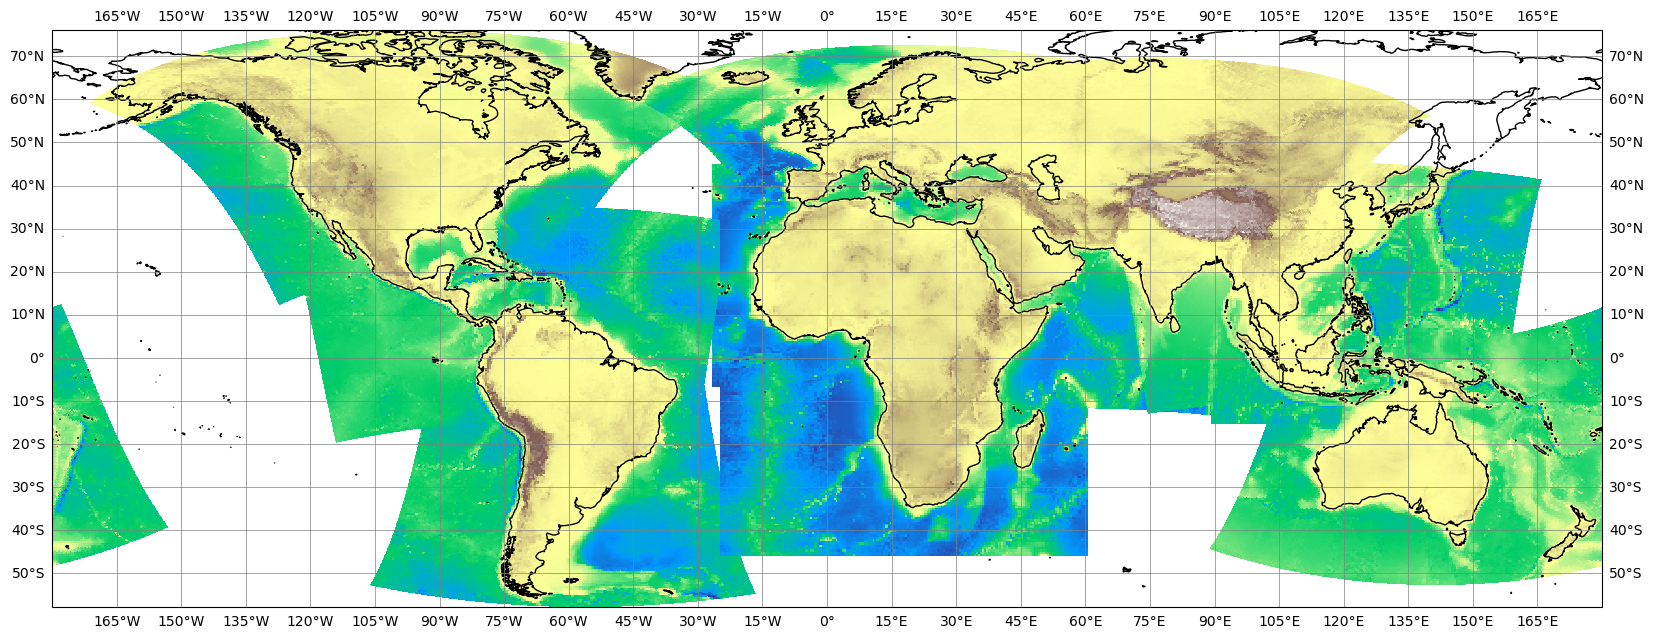

In [17]:
plots(
    [
        cx.cordex_domain(name, dummy="topo")
        for name in cx.tables.domains.index
        if name.endswith("-22")
    ],
    borders=False,
)